In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import csv
import warnings
import os
from scipy.optimize import brentq
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter(action="ignore", category=UserWarning)
warnings.simplefilter("ignore", pd.errors.SettingWithCopyWarning)

folder = os.fsencode("data/football")
dataframes = []
for file in sorted(os.listdir(folder)):
    filename = os.fsdecode(file)
    if filename.endswith(".csv"):
        df = pd.read_csv("data/football/" + filename)
        dataframes.append(df)

data = pd.concat(dataframes, axis=0)

In [4]:
data = data[[
    "HomeTeam", "AwayTeam", "FTHG", "FTAG", "FTR",
    "B365>2.5", "B365<2.5"
]]
data = data.dropna()
data = data.reset_index(drop=True)

In [6]:
data.describe()

,FTHG,FTAG,B365>2.5,B365<2.5
count,2536.000000,2536.000000,2536.000000,2536.000000
mean,1.466088,1.277997,1.881573,2.030434
std,1.239883,1.146302,0.286984,0.361413
min,0.000000,0.000000,1.250000,1.400000
25%,1.000000,0.000000,1.660000,1.730000
50%,1.000000,1.000000,1.885000,2.000000
75%,2.000000,2.000000,2.080000,2.200000
max,8.000000,7.000000,3.000000,4.000000


In [8]:
data["booksum"] = (1/data["B365>2.5"]) + (1/data["B365<2.5"])

In [10]:
data.describe()

,FTHG,FTAG,B365>2.5,B365<2.5,booksum
count,2536.000000,2536.000000,2536.000000,2536.000000,2536.000000
mean,1.466088,1.277997,1.881573,2.030434,1.050146
std,1.239883,1.146302,0.286984,0.361413,0.011488
min,0.000000,0.000000,1.250000,1.400000,1.017818
25%,1.000000,0.000000,1.660000,1.730000,1.048346
50%,1.000000,1.000000,1.885000,2.000000,1.054225
75%,2.000000,2.000000,2.080000,2.200000,1.057111
max,8.000000,7.000000,3.000000,4.000000,1.084629


In [12]:
data["multiplicativeOver"] = 1 / (data["B365>2.5"] * data["booksum"])
data["multiplicativeUnder"] = 1 / (data["B365<2.5"] * data["booksum"])

In [14]:
def f(odds: list, k: float) -> float:
    total = 0
    for odd in odds:
        total += (1/odd)**k
    return total - 1

def df(odds: list, k: float) -> float:
    total = 0
    for odd in odds:
        total += (1/odd)**k * np.log(1/odd)
    return total


def getPowerProbs(odds: list) -> list:
    xn = 1
    xn1 = 0
    epsilon = 1e-8

    while np.abs(xn1 - xn) > epsilon:
        xn = xn1
        xn1 = xn - (f(odds, xn) / df(odds, xn))

    newOdds = np.power(odds, xn1)
    newProbs = np.divide(1, newOdds)
    return newProbs

def getPowerProbsRow(row):
    odds = [row["B365>2.5"], row["B365<2.5"]]
    probs = getPowerProbs(odds)
    return pd.Series({"powerOver": probs[0], "powerUnder": probs[1]})

data[["powerOver", "powerUnder"]] = data.apply(getPowerProbsRow, axis=1)

In [18]:
def getShinProbabilities(odds):
    odds = np.array(odds)
    pi = 1/odds
    Pi = np.sum(pi)

    def p_i(z, pi_i):
        numerator = -z + np.sqrt(z**2 + 4*(1-z)*(pi_i**2 / Pi))
        denominator = 2*(1-z)
        return numerator / denominator

    def g(z):
        return sum(p_i(z, pi_i) for pi_i in pi) - 1

    z_star = brentq(g, 1e-8, 1 - 1e-8)
    probs = np.array([p_i(z_star, pi_i) for pi_i in pi])

    return probs, z_star

def getShinProbabilitiesRow(row):
    odds = [row["B365>2.5"], row["B365<2.5"]]
    probs, z_star = getShinProbabilities(odds)
    return pd.Series({"shinOver": probs[0], "shinUnder": probs[1], "z": z_star})

data[["shinOver", "shinUnder", "z"]] = data.apply(getShinProbabilitiesRow, axis=1)

In [20]:
data.describe()

,FTHG,FTAG,B365>2.5,B365<2.5,booksum,multiplicativeOver,multiplicativeUnder,powerOver,powerUnder,shinOver,shinUnder,z
count,2536.000000,2536.000000,2536.000000,2536.000000,2536.000000,2536.000000,2536.000000,2536.000000,2536.000000,2536.000000,2536.000000,2536.000000
mean,1.466088,1.277997,1.881573,2.030434,1.050146,0.517675,0.482325,0.519160,0.480840,0.518643,0.481357,0.050230
std,1.239883,1.146302,0.286984,0.361413,0.011488,0.076924,0.076924,0.083264,0.083264,0.081062,0.081062,0.011523
min,0.000000,0.000000,1.250000,1.400000,1.017818,0.318182,0.238095,0.304933,0.217648,0.309524,0.225000,0.017818
25%,1.000000,0.000000,1.660000,1.730000,1.048346,0.454068,0.430052,0.449938,0.423965,0.451367,0.426068,0.048543
50%,1.000000,1.000000,1.885000,2.000000,1.054225,0.515385,0.484615,0.515991,0.484009,0.515794,0.484206,0.054254
75%,2.000000,2.000000,2.080000,2.200000,1.057111,0.569948,0.545932,0.576035,0.550062,0.573932,0.548633,0.057263
max,8.000000,7.000000,3.000000,4.000000,1.084629,0.761905,0.681818,0.782352,0.695067,0.775000,0.690476,0.084973


In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# y=1 if over 2.5 goals, y=0 if under
y = ((data["FTHG"] + data["FTAG"]) > 2.5).astype(int)

X = pd.DataFrame({
    "odds_over":  data["B365>2.5"],
    "odds_under": data["B365<2.5"],
}, index=data.index)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)
probs_over = model.predict_proba(X_test)[:, 1]

data["logisticOver"]  = np.nan
data["logisticUnder"] = np.nan
data.loc[X_test.index, "logisticOver"]  = probs_over
data.loc[X_test.index, "logisticUnder"] = 1 - probs_over

data_test = data.loc[X_test.index].copy()
data_test.head()

,HomeTeam,AwayTeam,FTHG,FTAG,FTR,B365>2.5,B365<2.5,booksum,multiplicativeOver,multiplicativeUnder,powerOver,powerUnder,shinOver,shinUnder,z,logisticOver,logisticUnder
1607,Inter,Bologna,3,1,H,1.44,2.75,1.058081,0.656325,0.343675,0.670328,0.329672,0.665404,0.334596,0.058473,0.611195,0.388805
173,Napoli,Venezia,1,0,H,1.62,2.30,1.052067,0.586735,0.413265,0.593607,0.406393,0.591251,0.408749,0.052155,0.575044,0.424956
463,Roma,Monza,1,0,H,1.95,1.95,1.025641,0.500000,0.500000,0.500000,0.500000,0.500000,0.500000,0.025641,0.493673,0.506327
2352,Sassuolo,Roma,0,1,A,2.10,1.73,1.054225,0.451697,0.548303,0.447710,0.552290,0.449078,0.550922,0.054254,0.458222,0.541778
2089,Bologna,Verona,1,1,D,1.80,2.00,1.055556,0.526316,0.473684,0.528543,0.471457,0.527778,0.472222,0.055565,0.533909,0.466091


In [24]:
actual_over = ((data_test["FTHG"] + data_test["FTAG"]) > 2.5).astype(int)

def brier(prob_over_col):
    q = np.where(actual_over == 1, data_test[prob_over_col], 1 - data_test[prob_over_col])
    return ((q - 1) ** 2).sum() / len(q)

print(brier("multiplicativeOver"))
print(brier("powerOver"))
print(brier("shinOver"))
print(brier("logisticOver"))

0.23824393578430997
0.23784670889187062
0.2379734360300933
0.23936955027782317


In [26]:
from sklearn.metrics import log_loss

actual_over = ((data_test["FTHG"] + data_test["FTAG"]) > 2.5).astype(int)

print("multiplicative:", log_loss(actual_over, data_test["multiplicativeOver"]))
print("power:         ", log_loss(actual_over, data_test["powerOver"]))
print("shin:          ", log_loss(actual_over, data_test["shinOver"]))
print("logistic:      ", log_loss(actual_over, data_test["logisticOver"]))

multiplicative: 0.6693392349778033
power:          0.668517721772193
shin:           0.6687787691607676
logistic:       0.6716963804506649


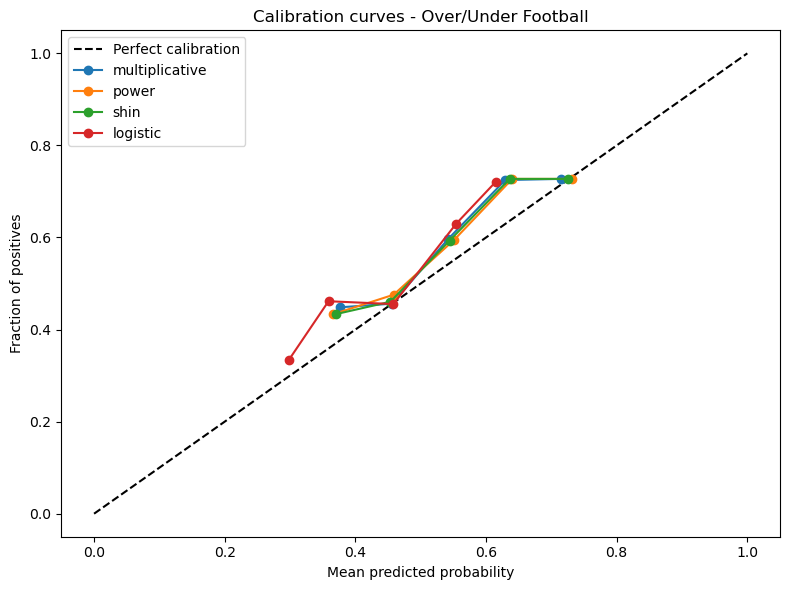

In [40]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

actual_over = ((data_test["FTHG"] + data_test["FTAG"]) > 2.5).astype(int)

models = {
    "multiplicative": data_test["multiplicativeOver"],
    "power":          data_test["powerOver"],
    "shin":           data_test["shinOver"],
    "logistic":       data_test["logisticOver"],
}

plt.figure(figsize=(8, 6))
plt.plot([0, 1], [0, 1], "k--", label="Perfect calibration")

for name, probs in models.items():
    fraction_of_positives, mean_predicted = calibration_curve(actual_over, probs, n_bins=10)
    plt.plot(mean_predicted, fraction_of_positives, marker="o", label=name)

plt.xlabel("Mean predicted probability")
plt.ylabel("Fraction of positives")
plt.title("Calibration curves - Over/Under Football")
plt.legend()
plt.tight_layout()
plt.savefig("OUCal.pdf")
plt.show()